# Data Mining

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, classification_report
from src.categories import tp_level_categories
from src.descriptions import df_measurements, df_descriptions
from src.eda import understand_features
from src.enums import files, keys, prefixes
from src.serialize import dump_to_file

In [20]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

IMAGE_PATH = 'images'
os.makedirs(IMAGE_PATH, exist_ok=True)

df = pd.read_csv(files['data/04-03-dataset.csv'])

## Understand features

In [11]:
understand_features(df, df_measurements, df_descriptions)

<class 'pandas.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   RSV_TP_LEVEL              138 non-null    str    
 1   nitrogen_dioxide (μg/m³)  138 non-null    float64
 2   carbon_monoxide (μg/m³)   138 non-null    float64
 3   uv_index ()               138 non-null    float64
 4   ozone (μg/m³)             138 non-null    float64
 5   MMWR_WEEK                 138 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 6.6 KB


,Measurement Type,Description
nitrogen_dioxide (μg/m³),ratio,Vehicle emissions can cause airway inflammation.
carbon_monoxide (μg/m³),ratio,"Odorless gas from combustion, reduces oxygen d..."
uv_index (),ratio,Measurement of the intensity of ultraviolet ra...
ozone (μg/m³),ratio,Created by chemical reactions between oxides o...
RSV_TP_LEVEL,ordinal,Positivity level based on 5 seasons of RSV data.
MMWR_WEEK,interval,Standardized CDC week number (1 to 52 or 53).


## Data Preparation

### Discretize target variable

In [12]:
df[keys['RSV_TP_LEVEL']] = pd.Categorical(
    df[keys['RSV_TP_LEVEL']],
    categories=tp_level_categories,
    ordered=True
)
df[keys['RSV_TP_LEVEL']] = df[keys['RSV_TP_LEVEL']].cat.codes

### Split dataset

In [13]:
target = df[keys['RSV_TP_LEVEL']]
features = df.drop(columns=['RSV_TP_LEVEL'])
n_splits = 5
time_series_split = TimeSeriesSplit(n_splits=n_splits)

folds = list(time_series_split.split(features))

for index, (train_index, test_index) in enumerate(folds):
    # Serialize the training folds to allow analysis in 04-03-data-mining-analyzer notebook.
    dump_to_file(df.iloc[train_index], prefixes['04_03_data_mining_folds_'] + str(index))

validation_folds = folds[0:n_splits-1]
test_fold = folds[-1]

### Random Forest Classifier

In [ ]:
def get_rf_classifier():
    return RandomForestClassifier(
        n_estimators=100,
        min_samples_leaf=3,
        min_samples_split=2,
        random_state=RANDOM_STATE
    )

## Training and Testing using RandomForest Classifier

In [ ]:
# random_forest_step_by_step_v2.ipynb
accs = []
n_run = 4
for i in range(n_run):
    xTrain, xTest, yTrain, yTest = train_test_split(
        features, target, test_size=0.3, stratify=target, random_state=i
    )
    random_forest = get_rf_classifier()
    random_forest.fit(xTrain, yTrain)
    acc = accuracy_score(yTest, random_forest.predict(xTest))
    accs.append(acc)
accs = np.array(accs)
print(f'Accuracy Score Mean: {accs.mean()}')

Accs Mean: 0.6488095238095238


fig = plt.figure()
plt.boxplot(accs)
plt.title("RF Accuracy Over Random Splits")
plt.ylabel("Accuracy")
plt.grid(True)
plt.savefig(os.path.join(IMAGE_PATH, "04-03-data-mining-rf-accuracy.png"), dpi=300)
plt.show()

## Feature Importances 

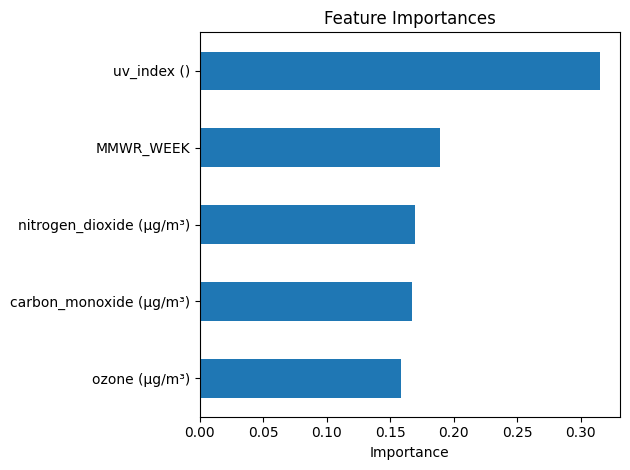

In [16]:
rf = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=2,
    max_features='sqrt', 
    min_samples_leaf=2, 
    n_jobs=-1, 
    random_state=RANDOM_STATE
).fit(features, target)


importances = pd.Series(rf.feature_importances_, index=features.columns).sort_values()
fig = plt.figure()
importances.plot(kind='barh')
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()